Heteroscedastic Regression with Uncertainty Estimation (Univariate Case)
___

In [12]:
from dynamodelx import UFA
from sklearn.datasets import fetch_california_housing, make_regression
from dynamodelx.plots import draw_plots

In [3]:
data = fetch_california_housing()
X, y = data.data, data.target

ufa = UFA(
    task='regression', 
    model_size='small', 
    input_dim=X.shape[1],
    output_dim=1, # Don't have to incorporate variance dimensions, model will take care of it.
    loss='gaussian_nll_loss',
    device='cuda',
    custom_architecture=None, 
    weights_init='he', 
    hidden_activation='relu',
    optimizer='adam',
    return_metrics=True,
    auto_build=True,
    multiclass=False,
    uncertainty=True # True for heteroscedastic regression
)

performance = ufa.train(
                    X=X,
                    y=y,
                    epochs=50,
                    learning_rate=0.01,
                    momentum=None,
                    val_size=0.2,
                    test_size=0.1,
                    batch_size=32
                )

Model Configuration:

  Task:               regression
  Model Size:         small
  Input Dimension:    8
  Output Dimension:   1
  Loss                gaussian_nll_loss
  Device:             cuda
  Hidden Activation:  relu
  Optimizer:          adam
  Weights Init:       he
  Uncertainty:        True
  Multiclass:         False
  Custom Architecture:None

Building the model ...

===== Built Model =====
Linear(in_features=8, out_features=64, bias=True)
ReLU()
Linear(in_features=64, out_features=32, bias=True)
ReLU()
Linear(in_features=32, out_features=2, bias=True)

Total parameters: 2,722
Trainable parameters: 2,722
Non-trainable parameters: 0

Model successfully built

Average train loss per sample : 0.5060836108832528 
Average validation loss per sample : 0.5592864891008813

For 10% Confidence Level --> PICP: 0.8130, MPIW: 1.0931

For 20% Confidence Level --> PICP: 0.6255, MPIW: 0.7179

For 30% Confidence Level --> PICP: 0.4327, MPIW: 0.4473

For 40% Confidence Level --> PICP: 0.22

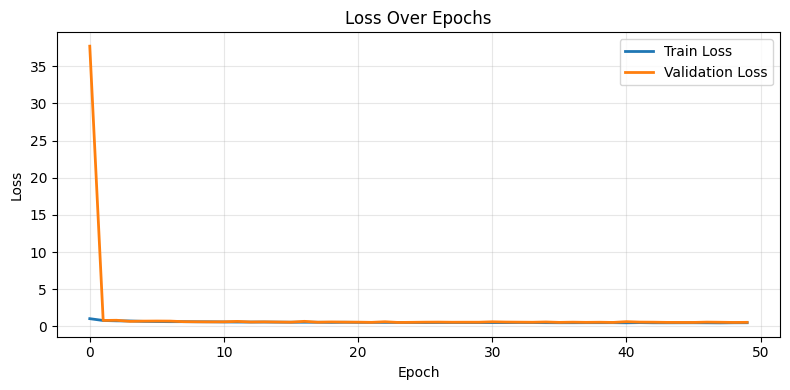

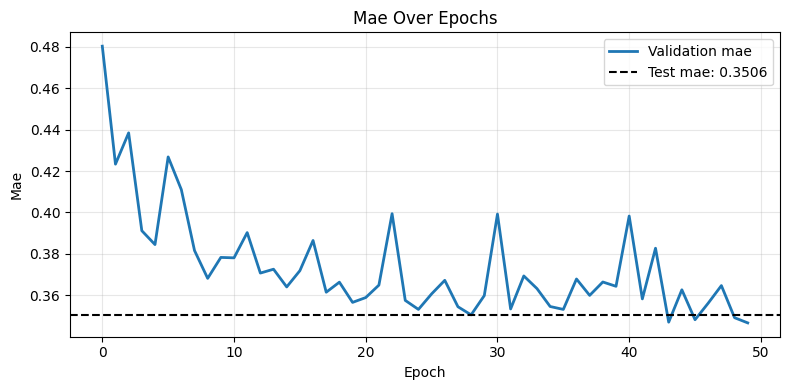

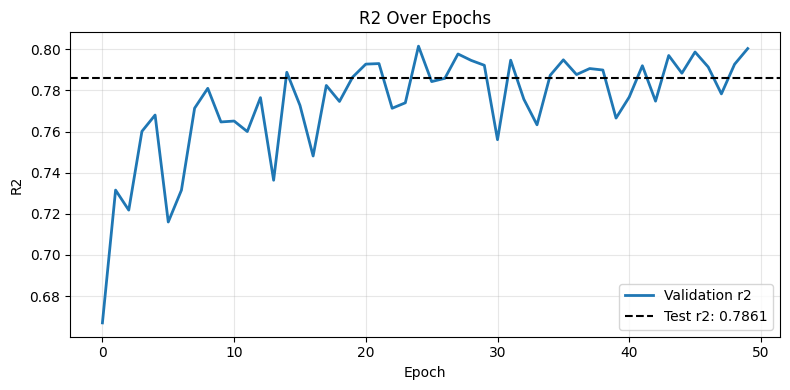

In [8]:
draw_plots(performance=performance)

In [9]:
performance.test

{'test_mae': 0.3506307601928711, 'test_r2': 0.7860837578773499}

In [10]:
predictions = ufa.predict(X[:5])
print('Predictions:', predictions[0])
print('Variance for each prediction:', predictions[1])

Predictions: [4.1236124 4.31705   4.017294  2.89248   2.6300032]
Variance for each prediction: [0.45859152 0.25571263 0.5241983  0.25975987 0.32419783]


In [17]:
ufa.save(path='univariate_uncertainty.pth')

Model successfully saved to: univariate_uncertainty.pth


Heteroscedastic Regression with Uncertainty Estimation (Multi-Target Case)
___

In [18]:
output_dim = 2

X, y  = make_regression(
    n_samples = 1000,
    n_features = 8,
    n_informative = 2,
    n_targets = output_dim
)

In [20]:
ufa = UFA(
    task='regression', 
    model_size='small', 
    input_dim=X.shape[1],
    output_dim=output_dim,
    loss='gaussian_nll_loss',
    device='cuda',
    custom_architecture=None, 
    weights_init='he', 
    hidden_activation='relu',
    optimizer='adamw',
    return_metrics=True,
    auto_build=True,
    multiclass=False,
    uncertainty=True # True for heteroscedastic regression
)

performance = ufa.train(
                    X=X,
                    y=y,
                    epochs=50,
                    learning_rate=0.01,
                    momentum=None,
                    val_size=0.2,
                    test_size=0.1,
                    batch_size=32
                )

Model Configuration:

  Task:               regression
  Model Size:         small
  Input Dimension:    8
  Output Dimension:   2
  Loss                gaussian_nll_loss
  Device:             cuda
  Hidden Activation:  relu
  Optimizer:          adamw
  Weights Init:       he
  Uncertainty:        True
  Multiclass:         False
  Custom Architecture:None

Building the model ...

===== Built Model =====
Linear(in_features=8, out_features=64, bias=True)
ReLU()
Linear(in_features=64, out_features=32, bias=True)
ReLU()
Linear(in_features=32, out_features=4, bias=True)

Total parameters: 2,788
Trainable parameters: 2,788
Non-trainable parameters: 0

Model successfully built

Average train loss per sample : 2.533474712371826 
Average validation loss per sample : 2.6812617206573486

For 10% Confidence Level --> PICP: 0.8750, MPIW: 12.3934

For 20% Confidence Level --> PICP: 0.7450, MPIW: 8.1390

For 30% Confidence Level --> PICP: 0.5150, MPIW: 5.0713

For 40% Confidence Level --> PICP: 0.2

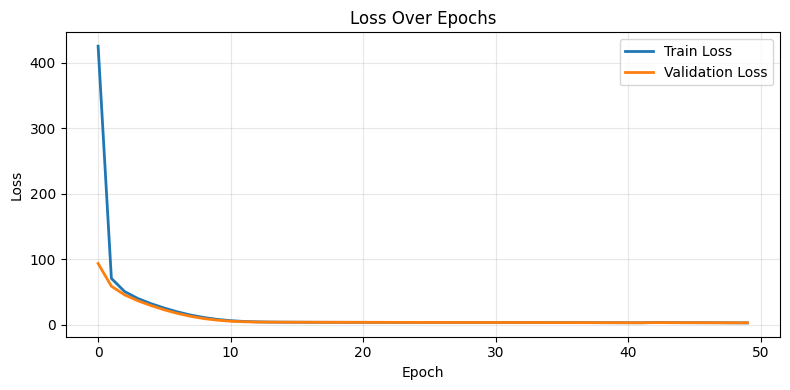

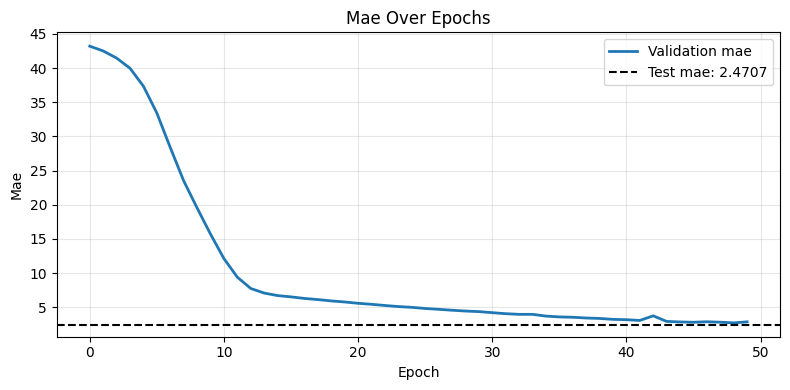

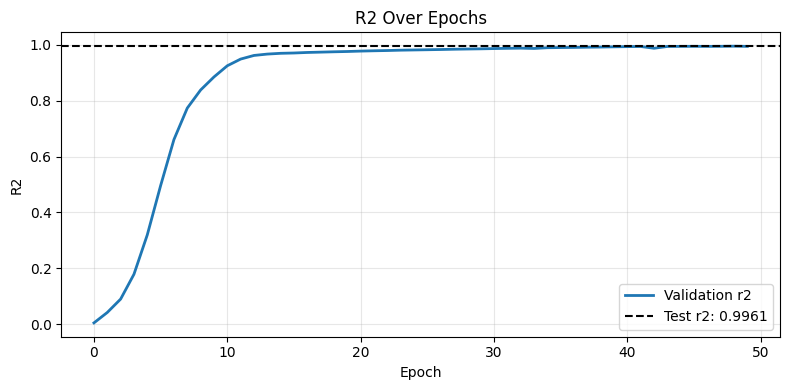

In [21]:
draw_plots(performance=performance)

In [22]:
performance.test

{'test_mae': 2.4706807136535645, 'test_r2': 0.996108889579773}

In [25]:
predictions = ufa.predict(X[:5])
print('Predictions:\n', predictions[0])
print('Variance for each prediction:\n', predictions[1])

Predictions:
 [[ -49.32767   -163.61432  ]
 [  16.351889    55.47839  ]
 [ -34.666924  -145.6237   ]
 [   3.4456668   25.428762 ]
 [  -9.369784   -43.02208  ]]
Variance for each prediction:
 [[ 2.482339  72.92365  ]
 [ 5.6637106 65.81427  ]
 [ 3.3325489 74.13551  ]
 [ 2.9251287 48.601746 ]
 [ 3.916924  55.044334 ]]


In [26]:
ufa.save(path='multi_target_uncertainty.pth')

Model successfully saved to: multi_target_uncertainty.pth
